# 💻 Ejercicios Computacionales — Capítulo 7: Cambios de Base

---

En estos ejercicios usarás **NumPy** para construir matrices de cambio de base,
convertir coordenadas, y explorar cómo cambia la representación de transformaciones.

| Ejercicio | Tema |
|:---:|:---|
| 1 | Construir $P$ y convertir coordenadas |
| 2 | Verificar que ir y volver da el original |
| 3 | Transformación de rotación en nueva base |
| 4 | Forma más simple de una matriz triangular |
| 5 | Visualización de dos bases en $\mathbb{R}^2$ |

> 💡 **Habilidad clave:** `np.linalg.inv(P)` y `P_inv @ A @ P`

## 🟦 Ejercicio 1: Construir $P$ y Convertir Coordenadas

Dada la base $\mathcal{B} = \{\mathbf{b}_1, \mathbf{b}_2\}$ con $\mathbf{b}_1 = (1,2)^\top$ y $\mathbf{b}_2 = (3,4)^\top$:

1. Construye la matriz de cambio de base $P$.
2. Calcula $P^{-1}$ y verifica $P P^{-1} = I$.
3. Convierte el vector $\mathbf{v} = (5,6)^\top$ a coordenadas en la base $\mathcal{B}$.
4. Convierte de vuelta y verifica que recuperas $\mathbf{v}$.
5. ¿Cuáles son las coordenadas de $\mathbf{b}_1$ y $\mathbf{b}_2$ en la base $\mathcal{B}$?

In [1]:
import numpy as np

# 1. Construir P
b1 = np.array([1., 2.])
b2 = np.array([3., 4.])
P = np.column_stack([b1, b2])
print("1. Matriz P:")
print(P)

# 2. Calcular P^{-1}
P_inv = np.linalg.inv(P)
print("\n2. P^{-1}:")
print(np.round(P_inv, 6))
print("   P @ P^{-1} = I:", np.allclose(P @ P_inv, np.eye(2)))

# 3. Convertir v a coordenadas en B
v = np.array([5., 6.])
v_B = P_inv @ v
print(f"\n3. v = {v} en base estándar")
print(f"   [v]_B = P^{{-1}} v = {np.round(v_B, 4)}")

# 4. Recuperar v
v_rec = P @ v_B
print(f"\n4. Recuperar: P @ [v]_B = {np.round(v_rec, 4)}")
print(f"   ¿Igual a v original? {np.allclose(v_rec, v)} ✓")

# 5. Coordenadas de b1 y b2 en B
print(f"\n5. Coordenadas de b1 en B: {P_inv @ b1}  → debería ser (1,0)")
print(f"   Coordenadas de b2 en B: {P_inv @ b2}  → debería ser (0,1)")
print("   (Los vectores de la base tienen coordenadas canónicas en su propia base ✓)")

1. Matriz P:
[[1. 3.]
 [2. 4.]]

2. P^{-1}:
[[-2.   1.5]
 [ 1.  -0.5]]
   P @ P^{-1} = I: True

3. v = [5. 6.] en base estándar
   [v]_B = P^{-1} v = [-1.  2.]

4. Recuperar: P @ [v]_B = [5. 6.]
   ¿Igual a v original? True ✓

5. Coordenadas de b1 en B: [1. 0.]  → debería ser (1,0)
   Coordenadas de b2 en B: [0. 1.]  → debería ser (0,1)
   (Los vectores de la base tienen coordenadas canónicas en su propia base ✓)


## 🟩 Ejercicio 2: La Conversión es Invertible

Una propiedad fundamental: **convertir a $\mathcal{B}$ y luego de vuelta** da el vector original.

Verifica algebraicamente y computacionalmente que:
$$P \cdot (P^{-1} \mathbf{v}) = \mathbf{v} \quad \text{para todo } \mathbf{v}$$

1. Prueba con 5 vectores aleatorios.
2. Prueba que si $[\mathbf{w}]_\mathcal{B} = \mathbf{c}$, entonces $[P\mathbf{c}]_\mathcal{B} = \mathbf{c}$.

In [2]:
import numpy as np

# Base B
b1 = np.array([1., 2.]); b2 = np.array([3., 4.])
P = np.column_stack([b1, b2])
P_inv = np.linalg.inv(P)

# 1. Probar con 5 vectores aleatorios
np.random.seed(42)
print("1. Verificación P @ P^{-1} v = v para 5 vectores aleatorios:")
print(f"   {'Vector v':<25} {'P @ P^{{-1}} v':<25} {'Igual?'}")
print("   " + "-"*60)
for _ in range(5):
    v = np.random.randint(-5, 6, size=2).astype(float)
    v_B = P_inv @ v          # convertir a B
    v_rec = P @ v_B          # convertir de vuelta
    ok = np.allclose(v_rec, v)
    print(f"   {str(v):<25} {str(np.round(v_rec,4)):<25} {'✓' if ok else '✗'}")

# 2. Si c = [w]_B, entonces [Pc]_B = c
print("\n2. Si c = [w]_B, entonces P^{-1}(Pc) = c:")
for _ in range(3):
    c = np.random.randn(2)
    w = P @ c          # vector en estándar a partir de coords en B
    c_check = P_inv @ w  # recuperar coords en B
    print(f"   c = {np.round(c,3)} → P^{{-1}}(Pc) = {np.round(c_check,4)} — igual: {np.allclose(c_check, c)} ✓")

print("\n✅ La conversión de base es siempre reversible.")

1. Verificación P @ P^{-1} v = v para 5 vectores aleatorios:
   Vector v                  P @ P^{{-1}} v            Igual?
   ------------------------------------------------------------
   [ 1. -2.]                 [ 1. -2.]                 ✓
   [5. 2.]                   [5. 2.]                   ✓
   [-1.  1.]                 [-1.  1.]                 ✓
   [ 4. -3.]                 [ 4. -3.]                 ✓
   [1. 5.]                   [1. 5.]                   ✓

2. Si c = [w]_B, entonces P^{-1}(Pc) = c:
   c = [-2.011 -0.493] → P^{-1}(Pc) = [-2.011  -0.4928] — igual: True ✓
   c = [ 0.393 -0.929] → P^{-1}(Pc) = [ 0.3926 -0.9292] — igual: True ✓
   c = [ 0.08 -0.16] → P^{-1}(Pc) = [ 0.0798 -0.1595] — igual: True ✓

✅ La conversión de base es siempre reversible.


## 🟦 Ejercicio 3: Transformación de Rotación en Nueva Base

Sea $R_{45°}$ la matriz de rotación de $45°$:
$$R = \frac{\sqrt{2}}{2}\begin{pmatrix}1 & -1 \\ 1 & 1\end{pmatrix}$$

Sea $\mathcal{B} = \{(1,0)^\top, (0,1)^\top\}$ (misma base estándar pero rotada), o sea, usa la base:
$\mathbf{b}_1 = (1, 1)^\top / \sqrt{2}$ y $\mathbf{b}_2 = (-1, 1)^\top / \sqrt{2}$.

1. Calcula $R_{\mathcal{B}} = P^{-1} R P$.
2. ¿Qué estructura tiene $R_\mathcal{B}$? ¿Sorprende?
3. Visualiza el efecto de $R$ en la base estándar vs. en la base $\mathcal{B}$.

Rotación 45° en base estándar R:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

Rotación 45° en base B (R_B = P^{-1}RP):
[[ 0.707107 -0.707107]
 [ 0.707107  0.707107]]

¡R_B es la misma rotación! (una rotación pura es la misma en cualquier base ortogonal)


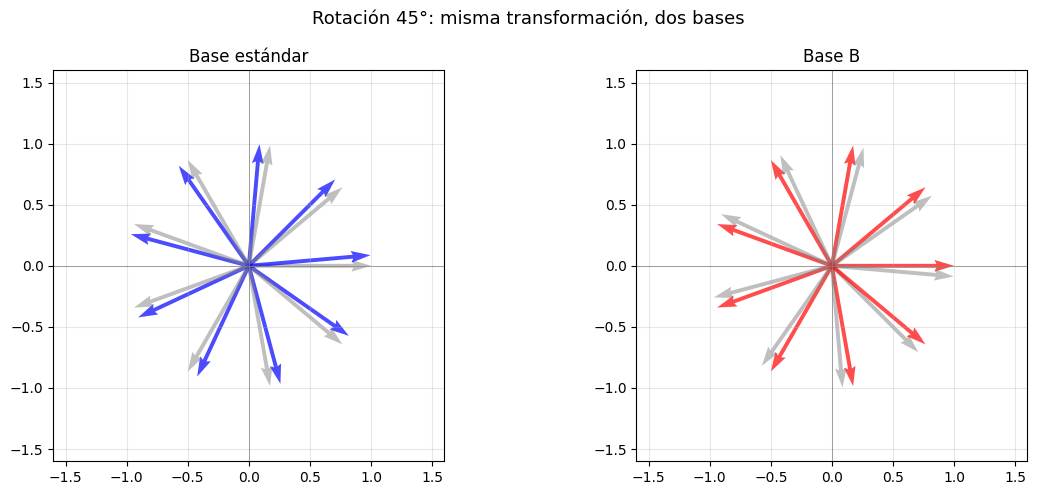

det(R) = 1.00, det(R_B) = 1.00


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Matriz de rotación 45°
theta = np.radians(45)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# Base B
b1 = np.array([1., 1.]) / np.sqrt(2)
b2 = np.array([-1., 1.]) / np.sqrt(2)
P = np.column_stack([b1, b2])

# Calcular R en base B
R_B = np.linalg.inv(P) @ R @ P

print("Rotación 45° en base estándar R:")
print(np.round(R, 4))
print("\nRotación 45° en base B (R_B = P^{-1}RP):")
print(np.round(R_B, 6))
print("\n¡R_B es la misma rotación! (una rotación pura es la misma en cualquier base ortogonal)")

# Visualizar efecto de R
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Rotación 45°: misma transformación, dos bases', fontsize=13)

angles = np.linspace(0, 2*np.pi, 9, endpoint=False)
vecs = np.array([np.cos(angles), np.sin(angles)])
Rv = R @ vecs
vecs_B = np.linalg.inv(P) @ vecs
Rv_B = R_B @ vecs_B

for ax, vs, Tvs, title, col in [
    (axes[0], vecs, Rv, 'Base estándar', 'blue'),
    (axes[1], vecs_B, Rv_B, 'Base B', 'red')
]:
    ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_title(title)
    for i in range(vs.shape[1]):
        ax.quiver(0,0,vs[0,i],vs[1,i],angles='xy',scale_units='xy',scale=1,
                  color='gray',width=0.01,alpha=0.5)
        ax.quiver(0,0,Tvs[0,i],Tvs[1,i],angles='xy',scale_units='xy',scale=1,
                  color=col,width=0.01,alpha=0.7)

plt.tight_layout(); plt.show()
print(f"det(R) = {np.linalg.det(R):.2f}, det(R_B) = {np.linalg.det(R_B):.2f}")

## 🟥 Ejercicio 4: Forma Más Simple de una Matriz Triangular

La matriz $A = \begin{pmatrix}2 & 1\\ 0 & 2\end{pmatrix}$ tiene autovalor doble $\lambda = 2$
pero **solo un autovector** (no es diagonalizable).

1. Verifica esto calculando los autovectores con NumPy.
2. Calcula $A^5$ directamente y usando el binomio de Newton (en forma triangular).
3. Usa la base $\{(1,0)^\top, (1,1)^\top\}$ y calcula $A_\mathcal{B}$.
4. Explica por qué esta matrix **no puede** ser diagonalizada.

In [4]:
import numpy as np

A = np.array([[2., 1.],
              [0., 2.]])

# 1. Autovectores
eigenvalues, eigenvectors = np.linalg.eig(A)
print("1. Autovalores:", eigenvalues)
print("   Autovectores (columnas):\n", eigenvectors)
print("   Solo hay un autovector independiente (columnas iguales) → no diagonalizable")

# 2. Calcular A^5
A5 = np.linalg.matrix_power(A, 5)
print("\n2. A^5 =\n", A5)
# Por binomio: A = 2I + N, N = [[0,1],[0,0]], N^2=0
# A^5 = 2^5 I + 5*2^4 N = 32I + 80N
A5_formula = 32*np.eye(2) + 80*np.array([[0.,1.],[0.,0.]])
print("   A^5 por binomio de Newton (2I+N)^5 = 32I + 5*16*N =\n", A5_formula)
print("   ¿Iguales?", np.allclose(A5, A5_formula))

# 3. Nueva base B = {(1,0), (1,1)}
b1 = np.array([1., 0.]); b2 = np.array([1., 1.])
P = np.column_stack([b1, b2])
A_B = np.linalg.inv(P) @ A @ P
print("\n3. A en base B = {(1,0),(1,1)}:")
print(np.round(A_B, 6))

print("\n4. Explicación: autovalor doble λ=2 con solo 1 autovector l.i.")
print("   No hay 2 vectores l.i. para formar la base → NO diagonalizable.")
print("   La mejor forma es la forma de Jordan (triangular con 1 en superdiagonal).")

1. Autovalores: [2. 2.]
   Autovectores (columnas):
 [[ 1.0000000e+00 -1.0000000e+00]
 [ 0.0000000e+00  4.4408921e-16]]
   Solo hay un autovector independiente (columnas iguales) → no diagonalizable

2. A^5 =
 [[32. 80.]
 [ 0. 32.]]
   A^5 por binomio de Newton (2I+N)^5 = 32I + 5*16*N =
 [[32. 80.]
 [ 0. 32.]]
   ¿Iguales? True

3. A en base B = {(1,0),(1,1)}:
[[2. 1.]
 [0. 2.]]

4. Explicación: autovalor doble λ=2 con solo 1 autovector l.i.
   No hay 2 vectores l.i. para formar la base → NO diagonalizable.
   La mejor forma es la forma de Jordan (triangular con 1 en superdiagonal).


## 🟩 Ejercicio 5: Visualización de Dos Bases en $\mathbb{R}^2$

Crea una visualización que muestre **el mismo vector** en dos bases distintas, con la cuadrícula
de cada base dibujada en el plano.

Bases a usar:
- $\mathcal{E}$: estándar $\{(1,0), (0,1)\}$
- $\mathcal{B}$: $\{(2,1)/\sqrt{5},\, (-1,2)/\sqrt{5}\}$ (base ortogonal no estándar)

Vector: $\mathbf{v} = (3, 2)^\top$.

Dibuja las líneas de la cuadrícula de cada base en colores diferentes.

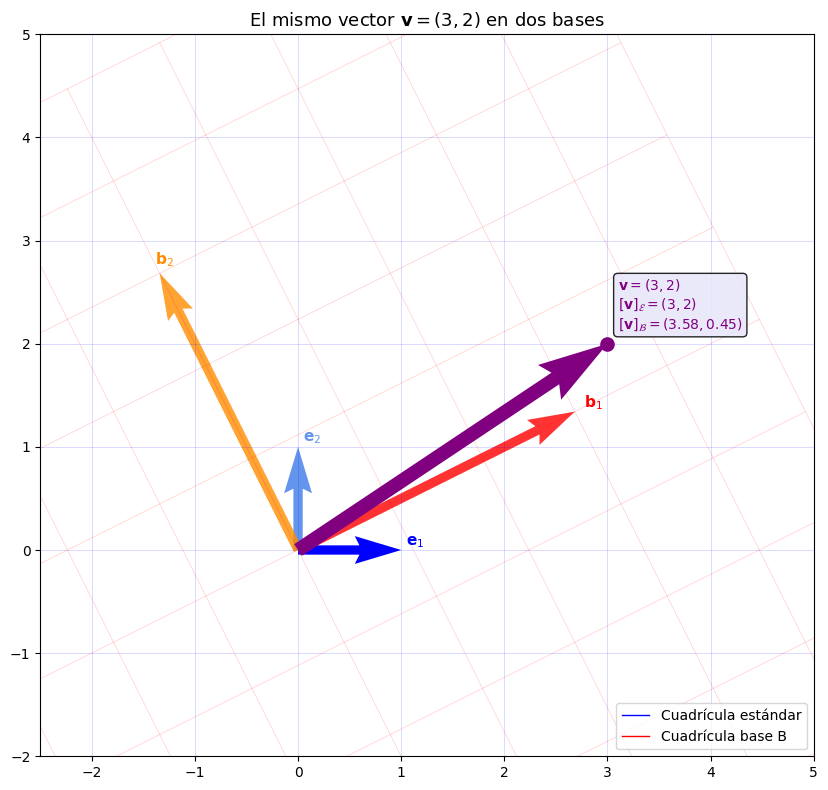

Mismo punto, coordenadas distintas:
  Base estándar: (3, 2)
  Base B: (3.5777, 0.4472)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Bases
e1, e2 = np.array([1.,0.]), np.array([0.,1.])
b1 = np.array([2.,1.]) / np.sqrt(5)
b2 = np.array([-1.,2.]) / np.sqrt(5)
P = np.column_stack([b1, b2])

v = np.array([3., 2.])
v_B = np.linalg.inv(P) @ v

fig, ax = plt.subplots(figsize=(9, 8))
ax.set_xlim(-2.5, 5); ax.set_ylim(-2, 5)
ax.set_aspect('equal')
ax.set_title('El mismo vector $\\mathbf{v}=(3,2)$ en dos bases', fontsize=13)

# Cuadrícula estándar
for i in range(-3, 6):
    ax.axhline(i, color='blue', lw=0.4, alpha=0.25)
    ax.axvline(i, color='blue', lw=0.4, alpha=0.25)

# Cuadrícula en base B
for k in np.arange(-4, 6, 1):
    # Líneas paralelas a b1
    start = k * b2 - 5*b1
    end   = k * b2 + 5*b1
    ax.plot([start[0],end[0]], [start[1],end[1]], color='red', lw=0.4, alpha=0.25)
    # Líneas paralelas a b2
    start2 = k * b1 - 5*b2
    end2   = k * b1 + 5*b2
    ax.plot([start2[0],end2[0]], [start2[1],end2[1]], color='red', lw=0.4, alpha=0.25)

# Ejes estándar
ax.quiver(0,0,1,0,angles='xy',scale_units='xy',scale=1,color='blue',width=0.012,label='$\\mathbf{e}_1$')
ax.quiver(0,0,0,1,angles='xy',scale_units='xy',scale=1,color='cornflowerblue',width=0.012,label='$\\mathbf{e}_2$')
ax.text(1.05,0.05,'$\\mathbf{e}_1$',color='blue',fontsize=11)
ax.text(0.05,1.05,'$\\mathbf{e}_2$',color='cornflowerblue',fontsize=11)

# Ejes base B
ax.quiver(0,0,b1[0]*3,b1[1]*3,angles='xy',scale_units='xy',scale=1,color='red',width=0.012,alpha=0.8)
ax.quiver(0,0,b2[0]*3,b2[1]*3,angles='xy',scale_units='xy',scale=1,color='darkorange',width=0.012,alpha=0.8)
ax.text(b1[0]*3.1,b1[1]*3.1,'$\\mathbf{b}_1$',color='red',fontsize=11)
ax.text(b2[0]*3.1,b2[1]*3.1,'$\\mathbf{b}_2$',color='darkorange',fontsize=11)

# El vector v
ax.quiver(0,0,v[0],v[1],angles='xy',scale_units='xy',scale=1,color='purple',width=0.018,zorder=5)
ax.scatter(*v,color='purple',s=90,zorder=10)

ax.text(v[0]+0.1,v[1]+0.15,
        f'$\\mathbf{{v}}=(3,2)$\n'
        f'$[\\mathbf{{v}}]_\\mathcal{{E}}=(3,2)$\n'
        f'$[\\mathbf{{v}}]_\\mathcal{{B}}=({v_B[0]:.2f},{v_B[1]:.2f})$',
        fontsize=10, color='purple',
        bbox=dict(boxstyle='round,pad=0.3',facecolor='lavender',alpha=0.85))

blue_line = mlines.Line2D([], [], color='blue', lw=1, label='Cuadrícula estándar')
red_line  = mlines.Line2D([], [], color='red',  lw=1, label='Cuadrícula base B')
ax.legend(handles=[blue_line, red_line], loc='lower right')
plt.tight_layout(); plt.show()
print(f"Mismo punto, coordenadas distintas:")
print(f"  Base estándar: (3, 2)")
print(f"  Base B: ({v_B[0]:.4f}, {v_B[1]:.4f})")